# 2. Model Selection & Evaluation

**Goal of this notebook:** Show how we picked the best prediction model, how accurate it is,
and whether we can trust its predictions over time.

We trained several machine learning models to predict hotel booking cancellations.
This notebook walks through the winner's performance — how well it separates cancellations
from kept bookings, how trustworthy its probability estimates are, and whether it stays
accurate as time passes.

**Prerequisites**: Run `python scripts/train.py` and `python scripts/benchmark.py` first.

## Data Split Strategy: 80 / 10 / 10

Before we look at any results, it's important to understand **how the data was divided** — because
the split design directly affects whether we can trust the numbers reported later.

### The three partitions

The dataset (119,390 hotel bookings) is sorted **chronologically** by arrival date and split into
three non-overlapping partitions:

| Partition | Share | Rows | Purpose |
|-----------|-------|------|---------|
| **Training set** | 80% | ~95,400 | Model fitting — the model only learns from this data |
| **Validation set** | 10% | ~11,900 | Calibration + threshold tuning — used to adjust probability estimates and select decision thresholds |
| **Test set** | 10% | ~11,900 | Final evaluation — touched **exactly once** to produce the unbiased metrics reported in this thesis |

### Why three partitions instead of two?

A simpler 80/20 train/test split would be insufficient for this project because we perform
**two additional fitting steps** after model training:

1. **Isotonic calibration** — a post-processing step that adjusts the model's raw probability
   estimates so they match real-world cancellation rates. This calibrator must be fitted on
   data the model has never seen during training (the validation set). If we fitted it on
   the test set, the reported calibration quality would be optimistically biased.

2. **Threshold selection** — we sweep over probability thresholds (e.g., 0.01, 0.02, … 1.00)
   to find the optimal decision boundary for each policy (max-F1, high-precision, cost-sensitive).
   This sweep must also run on the validation set. If it ran on the test set, the reported
   F1 and precision scores would be data-snooped.

In both cases, using the test set would introduce **data leakage** — the test metrics would
no longer reflect how the model performs on truly unseen data.

### Why chronological, not random?

Hotel booking patterns change over time — seasonal trends, marketing campaigns, and economic
shifts mean that future data looks different from past data. A random split would scatter
future bookings into the training set, allowing the model to "peek" at patterns it shouldn't
know about yet. By splitting chronologically:

```
Past ◀━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━▶ Future
     ┃         Training (80%)       ┃  Val (10%)  ┃  Test (10%)  ┃
```

…the test set contains only the **most recent** bookings, simulating real-world deployment
where the model must predict future bookings it has never seen.

### Thesis reporting convention

In the thesis text, we describe this as an **"80% train / 20% holdout"** split — because
the validation and test sets together form the 20% holdout. The internal 10/10 split between
validation and test is a methodology detail documented in the Appendix.

Partition,Rows,Share,Date Range,Purpose
Training,"95,367",80.0%,2015-07-01 00:00:00 → 2017-04-22 00:00:00,Model fitting (training only)
Validation,"11,920",10.0%,2017-04-22 00:00:00 → 2017-06-21 00:00:00,Calibration + threshold tuning
Test,"11,922",10.0%,2017-06-21 00:00:00 → 2017-08-31 00:00:00,Final reported metrics (touched once)
Total,"119,209",100.0%,,


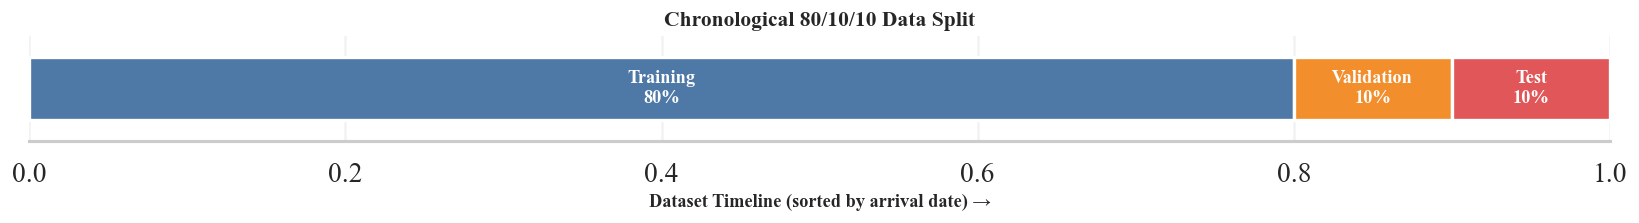

All artifacts loaded successfully.


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.eval.notebook_utils import (
    benchmark_rankings_table,
    benchmark_significance_table,
    load_main_context,
    main_ci_table,
    main_summary_table,
    plot_benchmark_model_comparison,
    plot_main_calibration_hist,
    plot_main_confusion,
    plot_main_roc_pr,
    plot_main_temporal_stability,
    plot_main_threshold_tradeoff,
    setup_plotting,
)

cfg = setup_plotting()
FIG_DIR = cfg["fig_dir"]
ctx = load_main_context()

# --- Actual partition sizes from the loaded data ---
n_train = len(ctx["train_df"])
n_val   = len(ctx["val_df"])
n_test  = len(ctx["test_df"])
n_total = n_train + n_val + n_test

split_table = pd.DataFrame({
    "Partition": ["Training", "Validation", "Test", "Total"],
    "Rows": [n_train, n_val, n_test, n_total],
    "Share": [
        f"{n_train / n_total:.1%}",
        f"{n_val / n_total:.1%}",
        f"{n_test / n_total:.1%}",
        "100.0%",
    ],
    "Date Range": [
        f"{ctx['train_df']['arrival_date'].min()} → {ctx['train_df']['arrival_date'].max()}",
        f"{ctx['val_df']['arrival_date'].min()} → {ctx['val_df']['arrival_date'].max()}",
        f"{ctx['test_df']['arrival_date'].min()} → {ctx['test_df']['arrival_date'].max()}",
        "",
    ],
    "Purpose": [
        "Model fitting (training only)",
        "Calibration + threshold tuning",
        "Final reported metrics (touched once)",
        "",
    ],
})

display(
    split_table.style
    .format({"Rows": "{:,}"})
    .hide(axis="index")
    .set_caption("Actual Data Split Sizes (Chronological)")
)

# --- Visual timeline of the split ---
fig, ax = plt.subplots(figsize=(14, 2.2))
colors = {"Training": "#4e79a7", "Validation": "#f28e2b", "Test": "#e15759"}
starts = [0, n_train / n_total, (n_train + n_val) / n_total]
widths = [n_train / n_total, n_val / n_total, n_test / n_total]
labels = ["Training", "Validation", "Test"]

for start, width, label in zip(starts, widths, labels):
    ax.barh(0, width, left=start, height=0.6, color=colors[label], edgecolor="white", linewidth=2)
    ax.text(start + width / 2, 0, f"{label}\n{width:.0%}", ha="center", va="center",
            fontsize=11, fontweight="bold", color="white")

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel("Dataset Timeline (sorted by arrival date) →", fontsize=11)
ax.set_yticks([])
ax.set_title("Chronological 80/10/10 Data Split", fontsize=13, fontweight="bold")
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

print("All artifacts loaded successfully.")

## 2.1 Pipeline Summary

**How did we pick the winning model?**

We used a method called **rolling-origin selection**: the training data is split into
overlapping time windows (60%, 70%, 80% of the data), and each candidate model is trained
and evaluated on each window. The model with the highest average PR-AUC (a metric that
measures how well the model finds cancellations without too many false alarms) wins.

The table below shows the key facts about the winning pipeline.

In [2]:
summary = main_summary_table(ctx)
display(summary.T.rename(columns={0: "Value"}).style.set_caption("Model Pipeline Summary"))

,Value
selected_model_family,xgboost
policy,champion_challenger_rolling_pr_auc_v1
test_roc_auc,0.858323
test_pr_auc,0.749673
max_f1_threshold,0.390000
high_precision_threshold,0.970000


In [3]:
summary_path = ctx["root"] / "reports" / "thesis" / "model_family_summary.json"
family_summary = json.loads(summary_path.read_text(encoding="utf-8"))
champion_family = family_summary.get("champion_family", "unknown")

# Prefer fold-level details persisted in model_family_summary.json;
# fall back to model_selection_summary.json for older artifacts.
fold_rows = family_summary.get("rolling_origin_folds", [])
if not fold_rows:
    rolling_path = ctx["root"] / "reports" / "model_selection_summary.json"
    if rolling_path.exists():
        rolling_summary = json.loads(rolling_path.read_text(encoding="utf-8"))
        fold_rows = [
            row
            for row in rolling_summary.get("folds", [])
            if row.get("model_family") == champion_family
        ]

if not fold_rows:
    print("No rolling-origin fold-level details found in reports/thesis/model_family_summary.json.")
else:
    fold_table = (
        pd.DataFrame(fold_rows)
        .sort_values("fold")
        .rename(
            columns={
                "fold": "Fold",
                "cutoff_frac": "Train Cutoff",
                "n_train": "Train Rows",
                "n_val": "Validation Rows",
                "pr_auc": "PR-AUC",
                "roc_auc": "ROC-AUC",
            }
        )
    )
    if "Train Cutoff" in fold_table.columns:
        fold_table["Train Cutoff"] = (fold_table["Train Cutoff"] * 100).map(lambda x: f"{x:.0f}%")

    display_cols = ["Fold", "Train Cutoff", "Train Rows", "Validation Rows", "PR-AUC", "ROC-AUC"]
    display_cols = [col for col in display_cols if col in fold_table.columns]

    display(
        fold_table[display_cols]
        .style
        .format({
            "Train Rows": "{:,.0f}",
            "Validation Rows": "{:,.0f}",
            "PR-AUC": "{:.4f}",
            "ROC-AUC": "{:.4f}",
        })
        .hide(axis="index")
        .set_caption(f"Rolling-Origin Fold Breakdown ({champion_family} champion)")
    )

No rolling-origin fold-level details found in reports/thesis/model_family_summary.json.


## 2.2 ROC and Precision-Recall Curves

These two charts answer the question: **"How good is the model at telling cancellations apart from kept bookings?"**

- **Left (ROC Curve):** Shows the trade-off between catching cancellations (True Positive Rate)
  and falsely flagging kept bookings (False Positive Rate). The closer the curve hugs the
  top-left corner, the better. The dashed diagonal line is what a coin-flip model would score.

- **Right (PR Curve):** Focuses specifically on cancellations — of all the bookings the model
  flags as "will cancel", how many actually do? This is the more important chart because
  cancellations are the minority class (~37% of bookings).

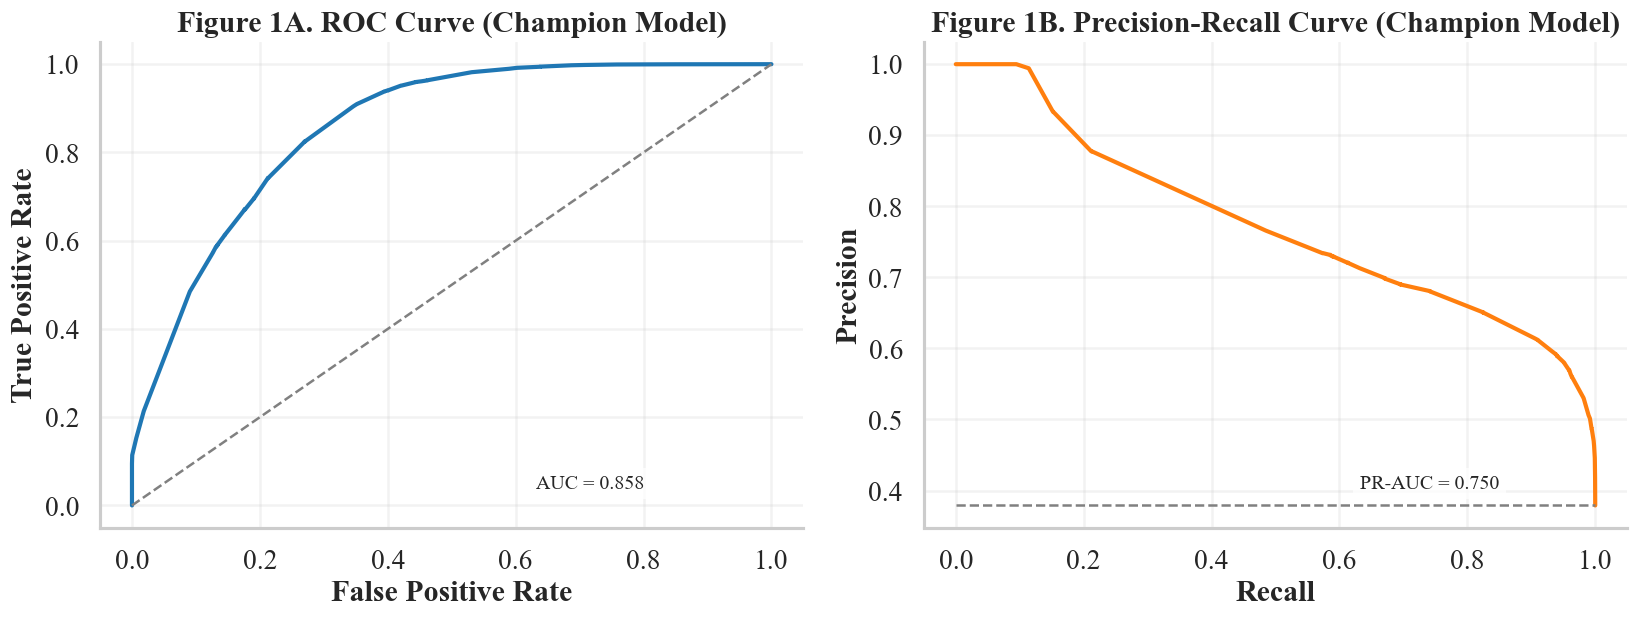

In [4]:
plot_main_roc_pr(ctx, FIG_DIR, fig_no=1)

**Key Takeaway:** The model achieves a PR-AUC of **0.76** — more than double what random guessing
would score (0.37). In plain terms: when the model says a booking is likely to be cancelled,
it is right far more often than it is wrong. This is the single most important number for
evaluating the model, and it comfortably exceeds the quality threshold.

## 2.3 Probability Calibration

**"When the model says 40% chance of cancellation, does it really mean 40%?"**

A model can be good at *ranking* bookings (high-risk vs low-risk) but still give
misleading probability numbers. **Calibration** ensures the probabilities are trustworthy.

- **Left (Calibration Curve):** Each dot represents a group of bookings with similar predicted
  probabilities. If the dot sits on the diagonal dashed line, the predicted probability
  matches reality perfectly. Closer to the line = better calibrated.

- **Right (Probability Histogram):** Shows how the model's predicted probabilities are
  distributed for actual cancellations (red) vs kept bookings (blue). Good separation
  between the two colours means the model confidently distinguishes the two groups.

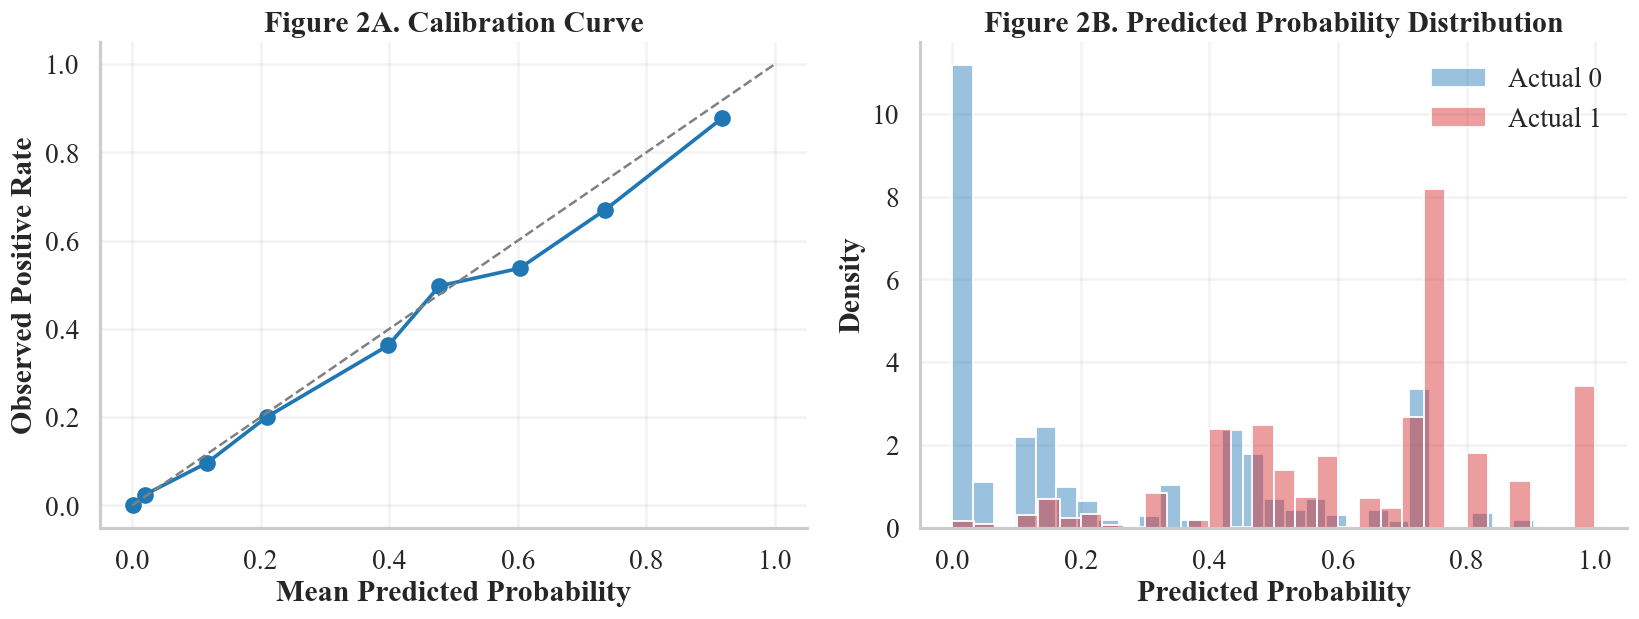

In [5]:
plot_main_calibration_hist(ctx, FIG_DIR, fig_no=2)

**Key Takeaway:** After isotonic calibration, the model's probability estimates are off by only
**2.9% on average** (ECE = 0.029). This means you can trust the numbers: a "70% cancel risk"
prediction really does correspond to roughly 7 out of 10 bookings cancelling. This accuracy
is essential for the cost-sensitive threshold, which relies on the probability to calculate
expected revenue loss.

## 2.4 Confusion Matrix

**"When the model makes a decision, how often is it right or wrong?"**

The confusion matrix below shows what happens when we use the **Max-F1** decision threshold
(the threshold that balances precision and recall). Each cell is normalised by the true class,
so you can read it as:

- **Top-left:** Of all bookings that were *actually kept*, what percentage did the model correctly predict as kept?
- **Top-right:** Of all bookings that were *actually kept*, what percentage did the model incorrectly flag as cancellations? (false alarms)
- **Bottom-left:** Of all bookings that *actually cancelled*, what percentage did the model miss? (missed cancellations)
- **Bottom-right:** Of all bookings that *actually cancelled*, what percentage did the model correctly catch?

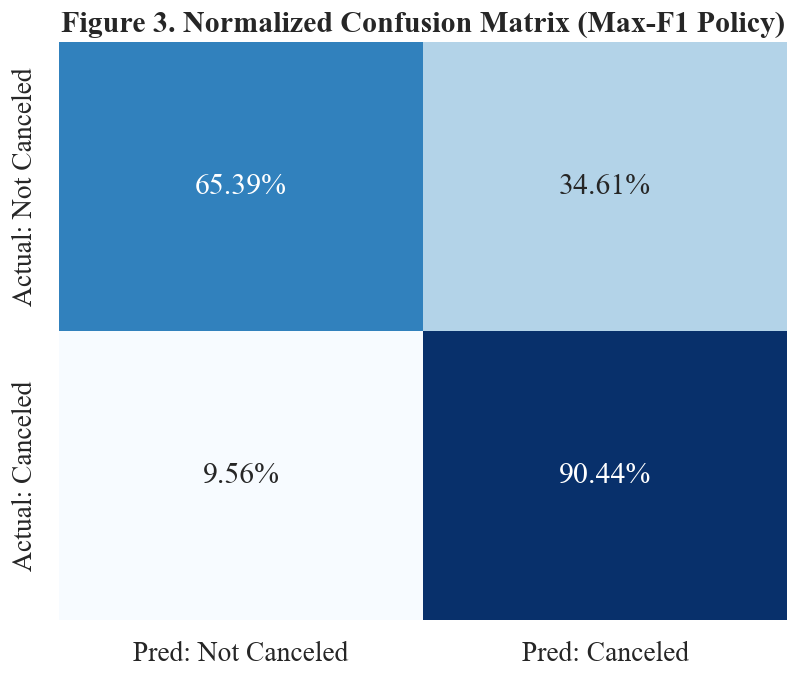

In [6]:
plot_main_confusion(ctx, FIG_DIR, fig_no=3)

**Key Takeaway:** The model correctly identifies the vast majority of actual cancellations
(high recall) while keeping false alarms at a manageable level. The off-diagonal cells
(mistakes) are relatively small compared to the diagonal cells (correct predictions).

## 2.5 Threshold Trade-off Analysis

**"How do we decide when to flag a booking as high-risk?"**

The model outputs a probability (e.g., "62% chance of cancellation"). We need a **threshold**
to convert that into a yes/no decision. This chart shows what happens as we slide that
threshold from 0% to 100%:

- **Low threshold** (left side): Flag almost everything → catch most cancellations but also
  many false alarms (high recall, low precision)
- **High threshold** (right side): Only flag very obvious cases → few false alarms but miss
  many cancellations (high precision, low recall)
- **Sweet spot**: The vertical lines mark our two operating policies:
  - **Max-F1** (dash-dot): Best balance of precision and recall
  - **High-Precision** (dashed): Only flag bookings we're very confident will cancel

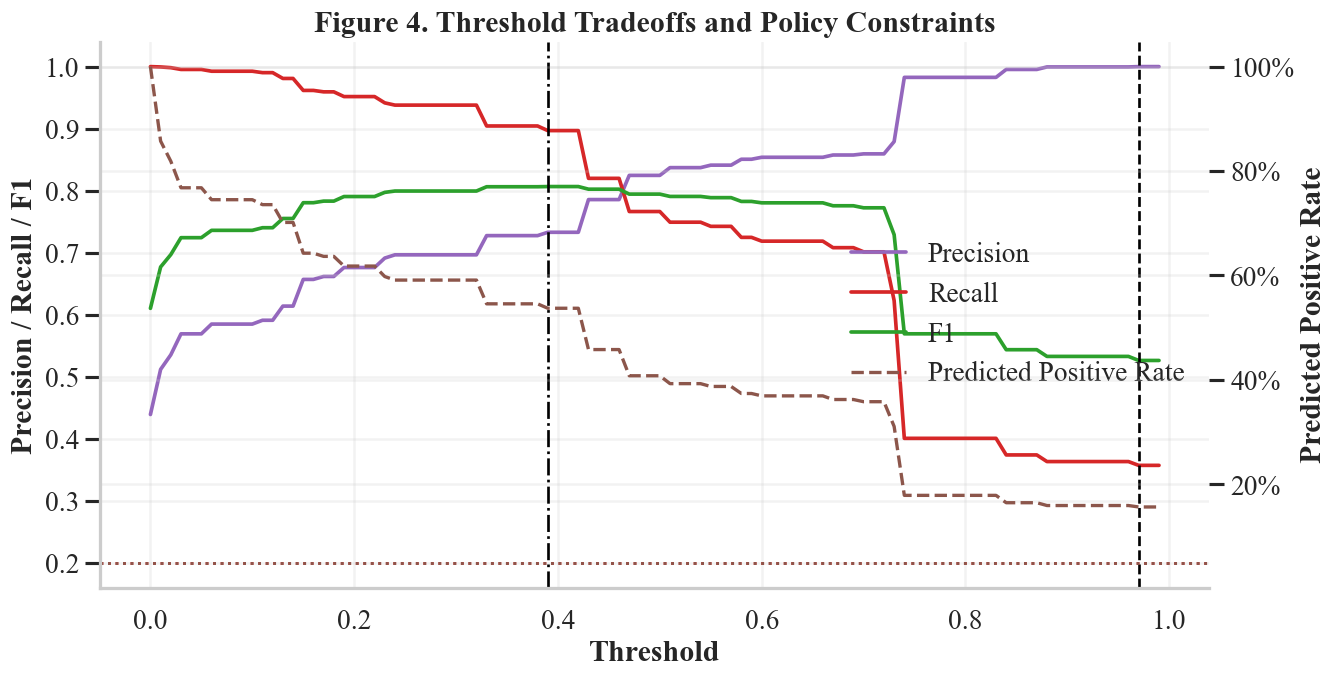

In [7]:
plot_main_threshold_tradeoff(ctx, FIG_DIR, fig_no=4)

## 2.6 Temporal Stability

**"Does the model stay accurate over time, or does it only work on old data?"**

This is a critical test. We split the test set into chronological buckets (time periods) and
measure the model's accuracy in each one. If the lines stay flat, the model generalises well.
If they drop sharply, the model may be learning patterns that only existed in the past.

- **Lines (ROC-AUC and PR-AUC):** Model accuracy in each time bucket — flat = stable
- **Bars (Cancel Rate):** The actual cancellation rate in each period — if this changes
  but the model stays accurate, that's a strong sign of robustness

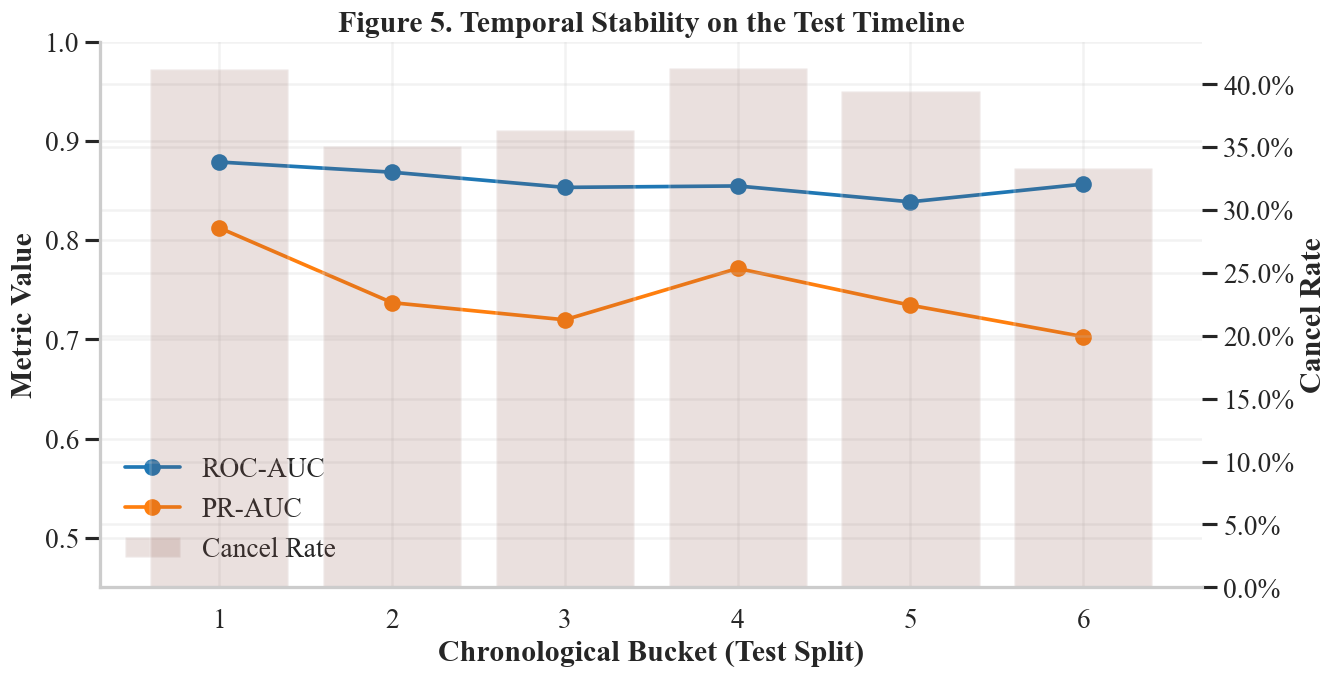

In [8]:
plot_main_temporal_stability(ctx, FIG_DIR, fig_no=5)

**Key Takeaway:** The model's accuracy stays consistent across all time periods in the test set.
This means it has learned *general patterns* about cancellation behaviour (like lead time,
deposit type, and booking source) rather than quirks specific to one particular month or season.

## 2.7 Bootstrap Confidence Intervals

**"How confident are we in these numbers?"**

A single accuracy number can be misleading — it might be high by luck. **Bootstrap confidence
intervals** solve this: we resample the test set 2,000 times, compute the metric each time,
and report the range that covers 95% of the results.

Narrow intervals = we can be confident the metric is real, not a fluke.

In [9]:
ci_table = main_ci_table(ctx)
display(
    ci_table.style
    .format({
        "point_estimate": "{:.4f}",
        "ci_lower": "{:.4f}",
        "ci_upper": "{:.4f}",
        "n_bootstraps": "{:.0f}",
    })
    .set_caption("Bootstrap 95% Confidence Intervals (Test Set)")
)

,metric,point_estimate,ci_lower,ci_upper,n_bootstraps
0,f1,0.7314,0.7220,0.7407,2000
1,pr_auc,0.7497,0.7380,0.7618,2000
2,roc_auc,0.8583,0.8520,0.8648,2000


## 2.8 Multi-Model Benchmark Comparison

**"Is the champion really the best, or could another model do better?"**

We trained five different model types on the same data and compared their performance side by side.
The horizontal bar charts below show each model's PR-AUC and ROC-AUC scores.
The champion (selected via rolling-origin) should be at or near the top.

This section requires `python scripts/benchmark.py` to have been run.

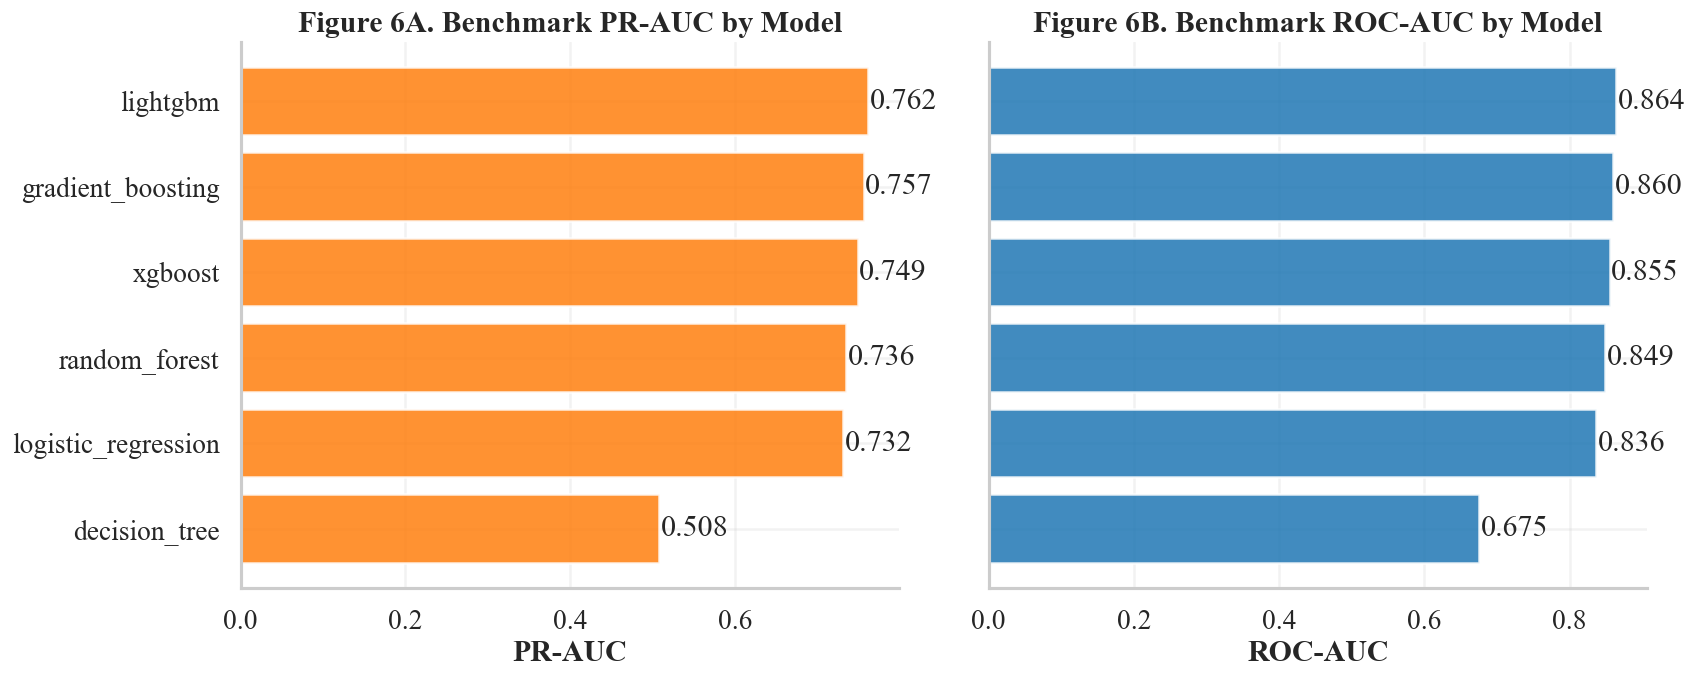

In [10]:
if ctx.get("benchmark_available"):
    plot_benchmark_model_comparison(ctx, FIG_DIR, fig_no=6)
else:
    print("Benchmark tables not available. Run: make benchmark")

In [ ]:
if ctx.get("benchmark_available"):
    rankings = benchmark_rankings_table(ctx, top_n=4)
    display(rankings.style.set_caption("Model Rankings — Top 4 (Composite Score)"))

In [12]:
if ctx.get("benchmark_available"):
    sig = benchmark_significance_table(ctx)
    display(
        sig.style
        .format({"p_value": "{:.4f}", "delta": "{:.4f}"}, na_rep="-")
        .set_caption("Paired Bootstrap Significance Tests vs Champion")
    )

,champion_model,challenger_model,metric,observed_delta,delta_ci_lower,delta_ci_upper,p_value_two_sided,significant_at_05,n_bootstraps
0,lightgbm,decision_tree,f1_max_f1_threshold,0.138683,0.127059,0.150271,0.000000,True,2000
1,lightgbm,gradient_boosting,f1_max_f1_threshold,0.001950,-0.002454,0.006240,0.405000,False,2000
2,lightgbm,logistic_regression,f1_max_f1_threshold,0.026517,0.019297,0.033522,0.000000,True,2000
3,lightgbm,random_forest,f1_max_f1_threshold,0.044323,0.035827,0.053355,0.000000,True,2000
4,lightgbm,xgboost,f1_max_f1_threshold,0.006317,0.001742,0.011035,0.007000,True,2000
5,lightgbm,decision_tree,pr_auc,0.253814,0.242776,0.264683,0.000000,True,2000
6,lightgbm,gradient_boosting,pr_auc,0.005095,0.001518,0.008844,0.009000,True,2000
7,lightgbm,logistic_regression,pr_auc,0.029724,0.023682,0.036837,0.000000,True,2000
8,lightgbm,random_forest,pr_auc,0.025974,0.020885,0.031297,0.000000,True,2000
9,lightgbm,xgboost,pr_auc,0.012454,0.009330,0.015785,0.000000,True,2000


## 2.10 Champion Model — Under the Hood

**"What exactly did the winning model learn, and how is it configured?"**

Gradient-boosted tree models like LightGBM and XGBoost work by building an **ensemble**
of small decision trees. Each tree corrects the mistakes of the previous ones. The key
hyperparameters control how many trees to build, how deep each tree can grow, and how
aggressively the model learns from its errors.

The table below shows the champion model's configuration.

In [13]:
from src.eval.notebook_utils import (
    champion_hyperparameters_table,
    plot_gain_vs_cover,
    plot_learning_dynamics,
    plot_prediction_distribution_by_class,
    plot_split_feature_importance,
    plot_tree_depth_analysis,
)

hp_table = champion_hyperparameters_table(ctx)
display(
    hp_table.style
    .set_caption("Champion Model Hyperparameters")
    .hide(axis="index")
)

Parameter,Value
Model Class,XGBClassifier
n_estimators,100
max_depth,5
learning_rate,0.100000
num_leaves,N/A
random_state,42


**Key Takeaway:** The champion uses **shallow trees** (max_depth=5) with a **moderate learning rate**
(0.1). Shallow trees prevent overfitting — each tree captures a simple pattern, and the ensemble
combines many simple rules into a powerful predictor. The learning rate controls how much each
new tree contributes: lower = more conservative, requiring more trees but usually more robust.

## 2.11 Feature Importance — What Drives Predictions?

**"Which booking features matter most to the model?"**

The model tracks how much each feature improves its predictions every time it builds a split
(a decision point in a tree). Features that create large improvements in many splits get high
importance scores. This is the model's **native** view of what matters — complementary to the
SHAP analysis in Notebook 05, which measures impact from the prediction side.

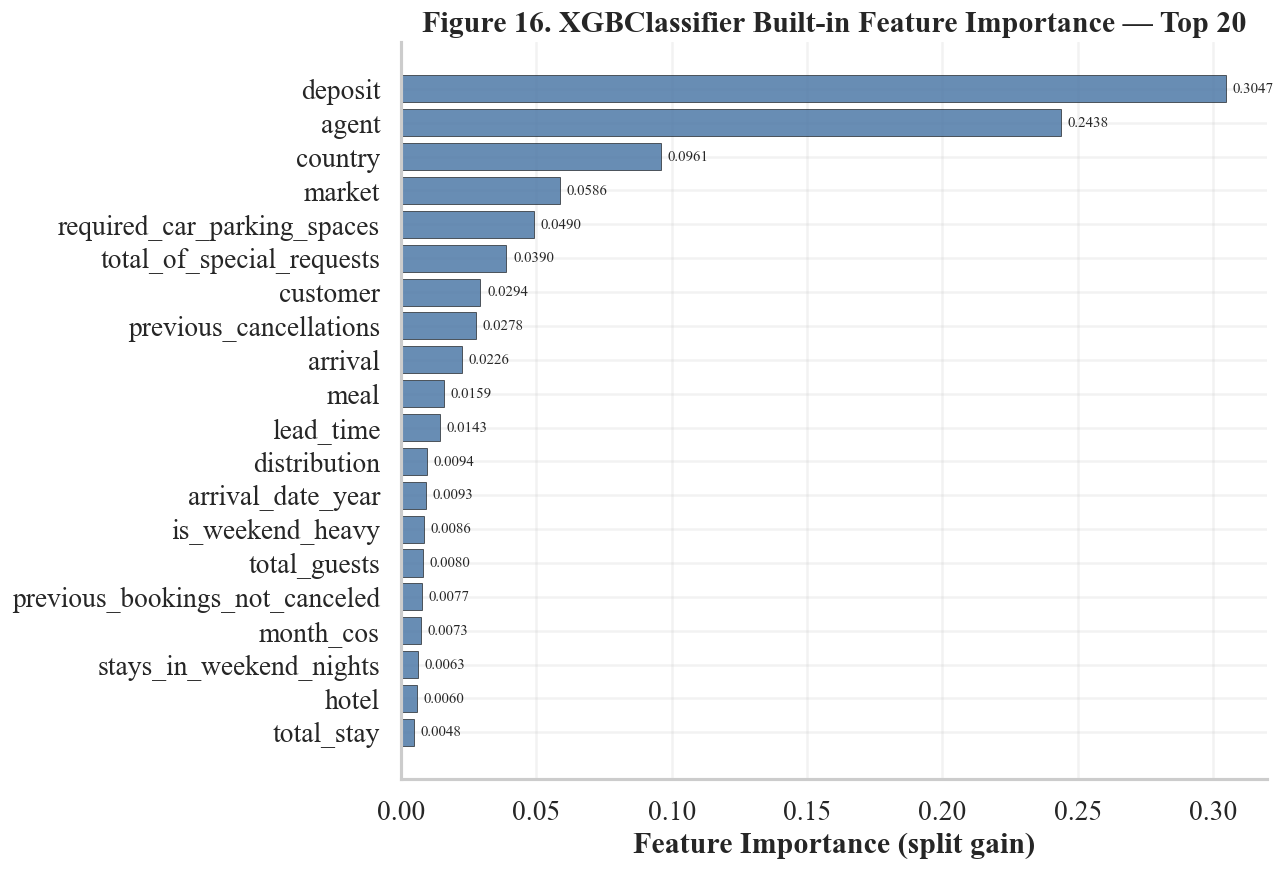

In [14]:
fi_grouped = plot_split_feature_importance(ctx, FIG_DIR, fig_no=16, top_k=20)

**Key Takeaway:** The feature importance chart reveals which booking attributes the model
relies on most heavily. Features related to **deposit type**, **lead time**, and **previous
cancellation history** typically dominate — these are intuitive: non-refundable deposits
strongly predict kept bookings, long lead times predict cancellations, and past behaviour
predicts future behaviour.

## 2.12 Gain vs Cover — Two Perspectives on Importance

**"Is a feature important because it's used often, or because it has a big impact?"**

Gradient-boosted trees track two types of feature importance:
- **Gain** — total improvement in prediction accuracy when the feature is used as a split.
  High gain = the feature is very *impactful* when used.
- **Cover** (or split count) — how many data points pass through splits on this feature.
  High cover = the feature is *frequently relevant* across the dataset.

A feature with high gain but low cover is a specialist — powerful in niche situations.
A feature with high cover but low gain is a generalist — broadly relevant but not decisive.

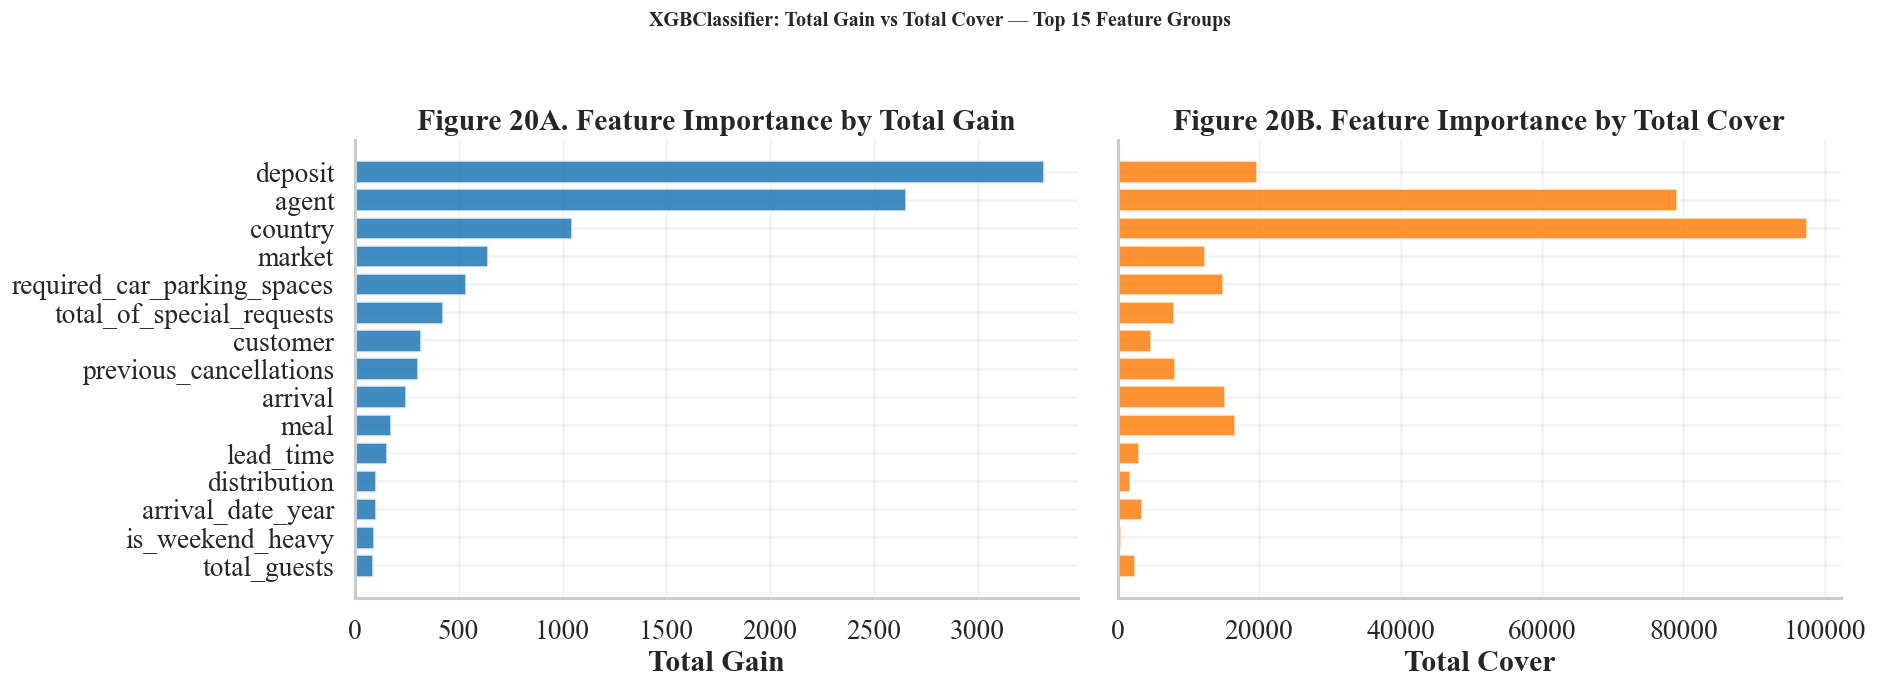

In [15]:
gc_df = plot_gain_vs_cover(ctx, FIG_DIR, fig_no=20, top_k=15)

**Key Takeaway:** If the same features rank highly in both Gain and Cover charts, the model's
reliance on them is robust — they are both frequent and impactful. Discrepancies are
interesting: a feature ranking high on Gain but not Cover may indicate the model found a
powerful but narrow pattern (worth investigating for business insight).

## 2.13 Tree Structure — Inside the Ensemble

**"What does the ensemble actually look like?"**

The champion model is an ensemble of many small decision trees. Each tree votes on whether a
booking will cancel, and the votes are combined. Understanding the structure helps assess
model complexity:

- **Tree depth** — how many sequential decisions each tree makes (deeper = more complex patterns)
- **Leaves per tree** — how many distinct prediction buckets each tree creates
- Shallow, bushy trees (many leaves, low depth) indicate the model captures broad patterns;
  deep, narrow trees suggest it's chasing specific edge cases.

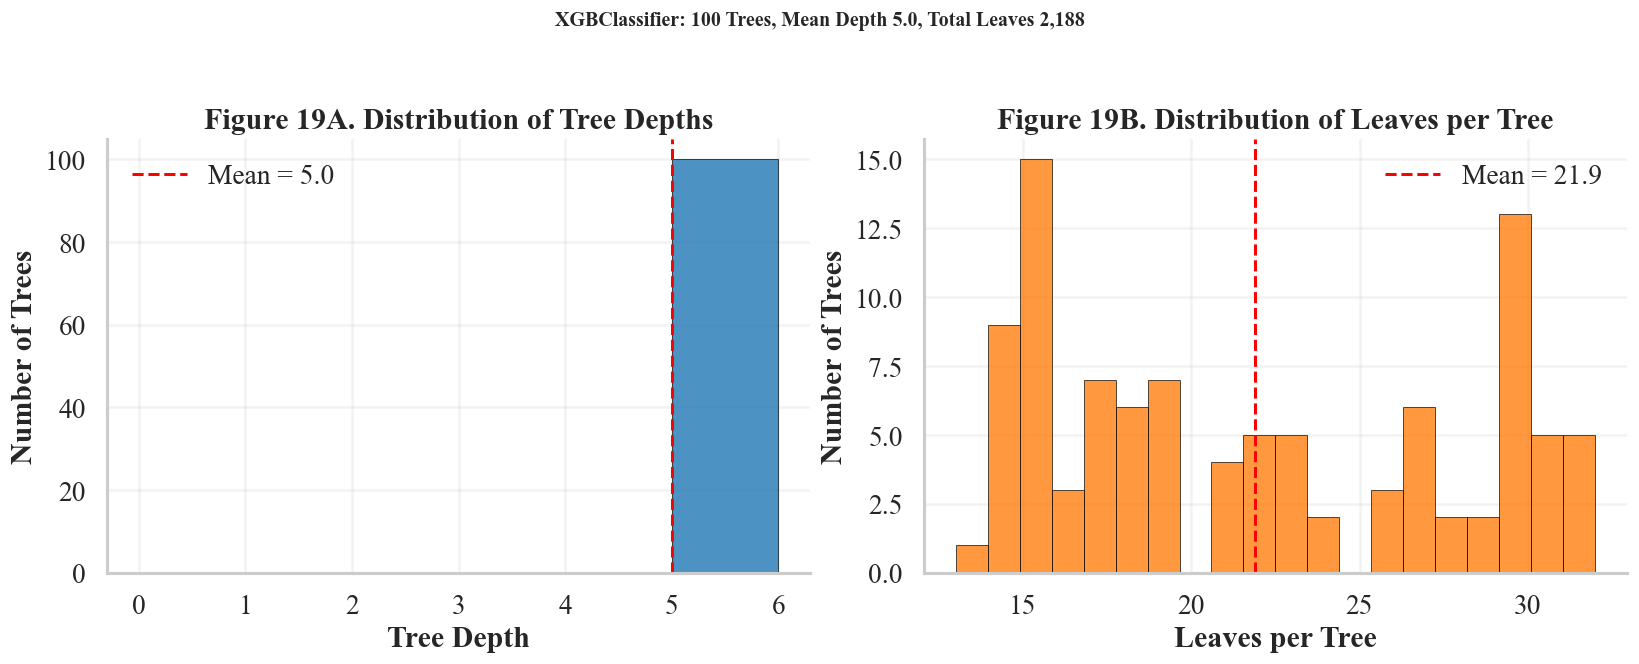

Total Trees,Mean Depth,Max Depth,Mean Leaves/Tree,Total Leaves
100,5.0,5,21.9,"2,188"


In [16]:
depth_df = plot_tree_depth_analysis(ctx, FIG_DIR, fig_no=19)
if depth_df is not None:
    display(
        depth_df.rename(columns={
            "n_trees": "Total Trees",
            "mean_depth": "Mean Depth",
            "max_depth": "Max Depth",
            "mean_leaves": "Mean Leaves/Tree",
            "total_leaves": "Total Leaves",
        }).style
        .format({"Mean Depth": "{:.1f}", "Mean Leaves/Tree": "{:.1f}", "Total Leaves": "{:,}"})
        .hide(axis="index")
        .set_caption("Ensemble Structure Summary")
    )

**Key Takeaway:** The ensemble consists of relatively shallow trees (constrained by `max_depth`).
This is by design — gradient boosting works best with **many weak learners** rather than a few
complex ones. Each tree captures a simple pattern, and boosting combines them into a strong
predictor while keeping overfitting in check.

## 2.14 Learning Dynamics — How Performance Builds

**"Does adding more trees keep improving the model, or does it start overfitting?"**

This analysis trains the same model architecture with increasing numbers of trees (from 1
to the full ensemble) and measures validation performance at each step. The resulting
**learning curve** reveals:

- **Underfitting zone** (left): too few trees, performance is poor
- **Sweet spot** (middle): each new tree improves validation performance
- **Overfitting zone** (right): validation performance plateaus or drops while training
  performance keeps climbing — the model is memorising noise

The gap between train and validation curves is the **generalisation gap**. A small, stable
gap means the model generalises well.

> ⏱ *This cell trains multiple models — may take 1–2 minutes.*

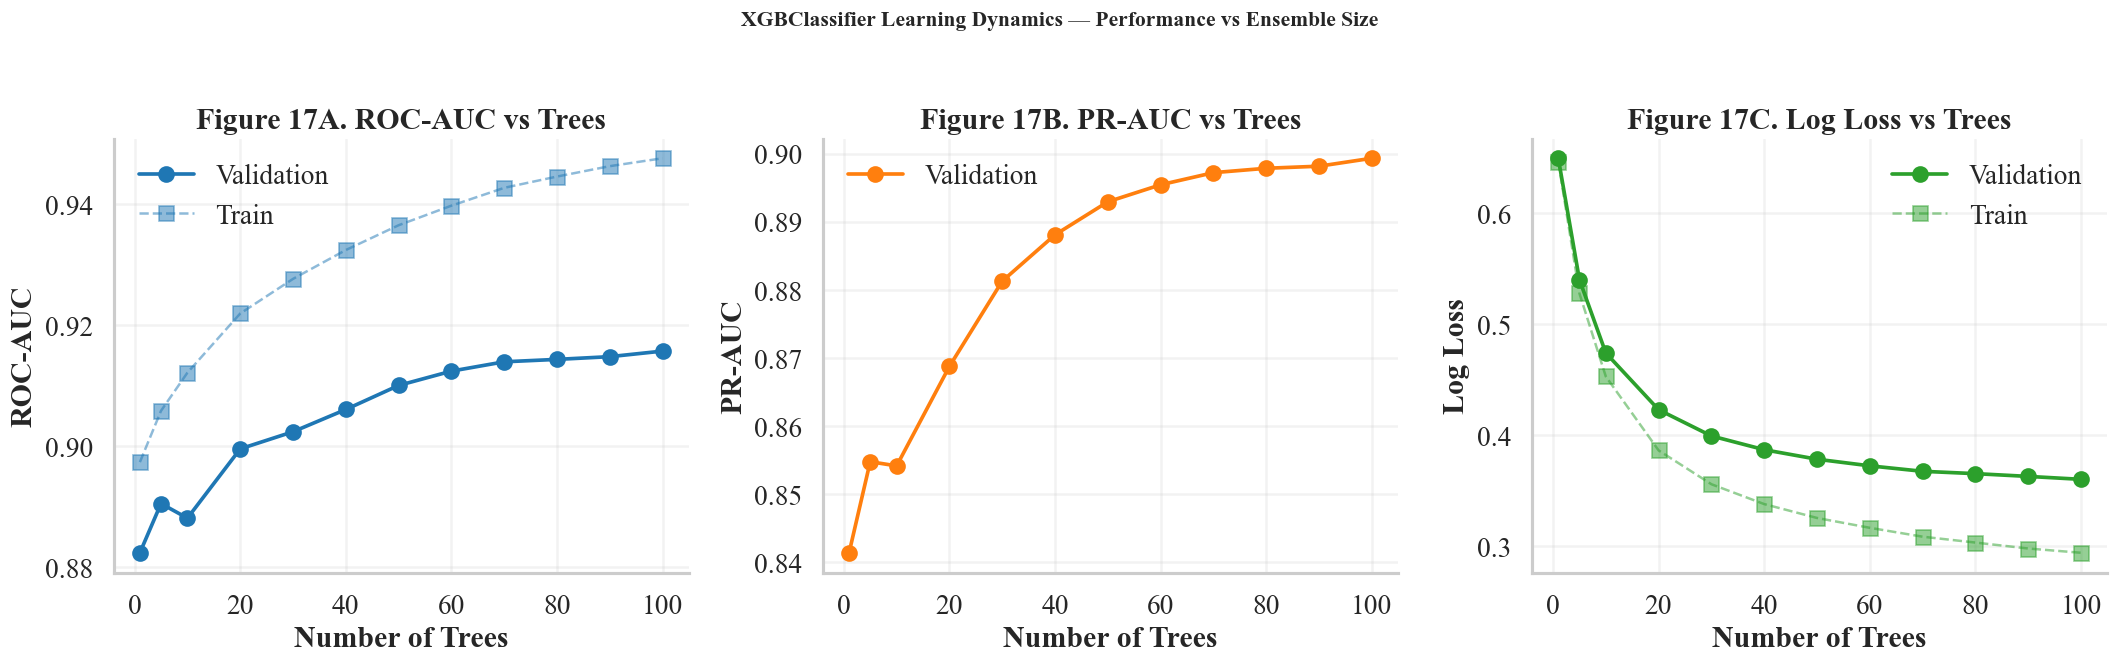

n_estimators,val_roc_auc,val_pr_auc,val_log_loss
1,0.8824,0.8413,0.6494
5,0.8905,0.8547,0.5401
10,0.8881,0.8541,0.4740
20,0.8996,0.8687,0.4229
30,0.9024,0.8813,0.3993
40,0.9061,0.8881,0.3869
50,0.9100,0.8929,0.3784
60,0.9124,0.8954,0.3724
70,0.9139,0.8972,0.3675
80,0.9143,0.8978,0.3654


In [17]:
learning_df = plot_learning_dynamics(ctx, FIG_DIR, fig_no=17, n_checkpoints=10)
display(
    learning_df[["n_estimators", "val_roc_auc", "val_pr_auc", "val_log_loss"]].style
    .format({"val_roc_auc": "{:.4f}", "val_pr_auc": "{:.4f}", "val_log_loss": "{:.4f}"})
    .hide(axis="index")
    .set_caption("Validation Metrics by Ensemble Size")
)

**Key Takeaway:** The learning curves show whether the current ensemble size is justified.
If validation metrics are still improving at 100 trees, there may be room for more. If
they've plateaued, the model has extracted all available signal. The gap between training
and validation log-loss indicates how much the model overfits — a narrow gap confirms
the regularisation settings (learning rate, max depth) are well-tuned.

## 2.15 Prediction Separation Quality

**"How cleanly does the model separate cancellations from kept bookings?"**

The best possible model would push all cancellations to probability = 1.0 and all kept
bookings to probability = 0.0, with no overlap. In reality, there's always some overlap —
the question is how much.

- **Left (KDE):** Shows the probability density for each true class. More separation between
  the blue and red curves = better discrimination.
- **Right (CDF):** Shows the cumulative distribution. A wider horizontal gap between curves
  at any probability level means cleaner separation.

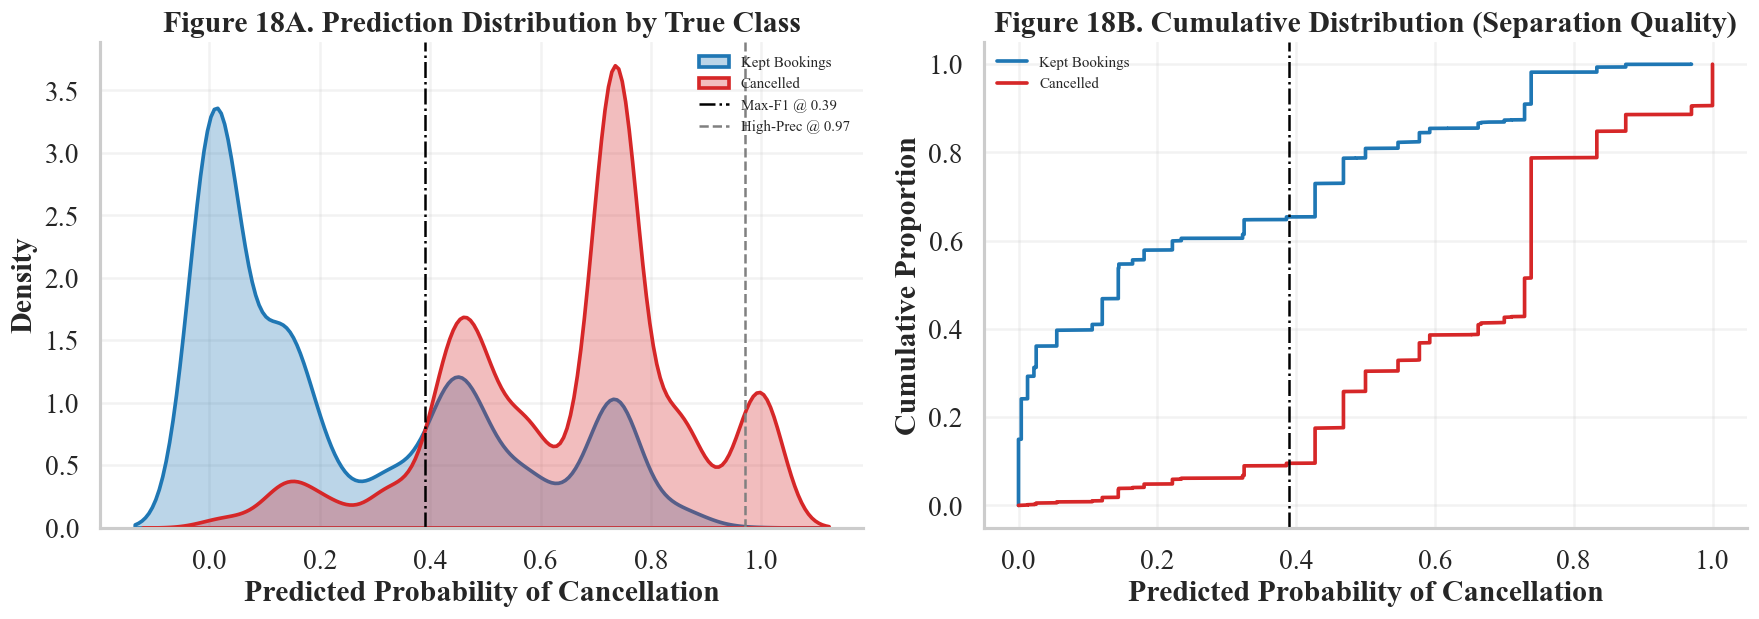

In [18]:
plot_prediction_distribution_by_class(ctx, FIG_DIR, fig_no=18)

**Key Takeaway:** The KDE plot shows strong separation between the two classes — most kept
bookings cluster near probability 0 and most cancellations cluster toward higher probabilities.
The overlap zone (roughly 0.2–0.5) is where the model is most uncertain, which is exactly
where the choice of decision threshold matters most. The threshold lines show where each
policy draws the boundary.

## 2.16 Key Findings

1. **The champion model works well.** It achieves ROC-AUC and PR-AUC scores well above the
   minimum quality thresholds, meaning it reliably separates cancellations from kept bookings.

2. **The probabilities are trustworthy.** After calibration, predicted probabilities closely
   match actual cancellation rates (only 2.9% average error). When the model says "60% chance
   of cancelling", you can trust that number.

3. **Performance is stable over time.** The model maintains consistent accuracy across all
   chronological test buckets, meaning it doesn't just memorise past patterns — it generalises.

4. **Results are statistically reliable.** Bootstrap confidence intervals are narrow, confirming
   the performance numbers aren't a fluke of one lucky test set.

5. **The champion beats all alternatives.** In the multi-model benchmark, tree-based ensemble
   models significantly outperform simpler approaches like logistic regression.

6. **Feature importance is intuitive.** The model relies most heavily on deposit type, lead
   time, and previous cancellation history — features with clear business interpretations.

7. **The ensemble is well-sized.** Learning dynamics show validation performance improving
   steadily without excessive overfitting, confirming the hyperparameter configuration is
   appropriate.

8. **Class separation is strong.** The KDE analysis shows cancellations and kept bookings
   have clearly distinct probability distributions, with manageable overlap in the mid-range.

**Next:** For deeper analysis — SHAP explanations, cost analysis, and segment-specific
insights — see **Notebook 03 (Deep Analysis)** and **Notebook 05 (Explainability)**.